# Pauli subcortical ROIs — SV_LL decoding: aggregate results

Aggregates per-subject ridge decoding results across Pauli subcortical ROIs.
Results directory: `mvpa_pauli_rois_SV_LL/sub-*/`

Sections:
1. Load and aggregate `roi_summary.csv`
2. Voxel retention QC
3. Prediction performance (Fisher z, R², brain map)
4. Trial-wise checks: SV_LL distribution, std ratio, true vs predicted
5. Baseline model and delay analysis (FDR-corrected)

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import seaborn as sns
from nilearn import plotting
from scipy import stats
from statsmodels.stats.multitest import multipletests

from dd_kable_analysis.config_loader import load_config

Matplotlib is building the font cache; this may take a moment.


In [2]:
cfg = load_config()
OUT_ROOT = cfg.output_root / 'mvpa_pauli_rois_SV_LL'
PAULI_DIR = cfg.masks_dir / 'pauli_subcort_rois_neurovault_collection_3145'
ATLAS_PATH = PAULI_DIR / 'pauli_roi_atlas_thr0.50_to-groupmask.nii.gz'
LABELS_TSV = PAULI_DIR / 'pauli_roi_atlas_thr0.50_to-groupmask_labels.tsv'

sub_dirs = sorted(OUT_ROOT.glob('sub-*'))
print(f'Results root: {OUT_ROOT}')
print(f'Subjects found: {len(sub_dirs)}')

Results root: /oak/stanford/groups/russpold/users/buckholtz/DD_Kable/derivatives/analysis_results/mvpa_pauli_rois_SV_LL
Subjects found: 123


In [3]:
roi_labels = pd.read_csv(LABELS_TSV, sep='\t', comment='#')
roi_labels = roi_labels.rename(columns={'label': 'roi_label', 'name': 'roi_name'})
roi_labels = roi_labels[['roi_label', 'roi_name']]
roi_labels

,roi_label,roi_name
0,1,Pu
1,2,Ca
2,3,NAC
3,4,EXA
4,5,GPe
5,6,GPi
6,7,SNc
7,8,RN
8,9,SNr
9,10,PBP


## 1  Aggregate subject-level ROI summary

In [4]:
summary_files = sorted(OUT_ROOT.glob('sub-*/roi_summary.csv'))
all_roi = pd.concat([pd.read_csv(f) for f in summary_files], ignore_index=True)
all_roi = all_roi.merge(roi_labels, on='roi_label', how='left')
print(f'{len(summary_files)} subjects, {len(all_roi)} subject x ROI rows')
all_roi.head()

111 subjects, 726 subject x ROI rows


,sub_id,roi_label,n_trials,n_runs,n_vox_preQC,n_vox_postQC,r,r2_cv,fisher_z,rmse,mean_alpha,roi_name
0,dmp0011,1,116,4,1655,1641,-0.195117,-0.053839,-0.197652,10.032145,751961.899926,Pu
1,dmp0011,2,116,4,1399,1369,-0.112414,-0.043095,-0.112891,9.980872,505916.933063,Ca
2,dmp0011,3,116,4,122,112,0.023875,0.008060,0.023880,9.733059,250496.276093,NAC
3,dmp0011,14,116,4,183,120,-0.017680,-0.008283,-0.017682,9.812911,250496.276093,HTH
4,dmp0019,1,115,4,1655,1655,-0.041067,-0.019456,-0.041090,14.669406,505455.054676,Pu


### Digesting the following result
  **The null is robust, not ambiguous.** The inner CV searched the full grid from 0.01 to 1,000,000 and consistently landed at the top. This isn't a case where the model found a modest alpha and just couldn't predict — it found no signal at any regularization level and maxed out.
                                                                                                                                                                       
  **The small negative R²_cv makes sense.** With alpha ~500K, the predictions are nearly but not exactly the training mean (tiny ridge coefficients push them slightly away). The baseline is the training mean, so the model is fractionally worse than pure mean-prediction — hence R²_cv of -0.01 to -0.02 rather than 0.
                                                                                                                                                                       
  **The consistency across ROIs is the finding.** All 8 ROIs show the same pattern — same alpha regime, same negative Fisher z range (-0.04 to -0.09), same RMSE (~10.8).  
  No ROI is an outlier in either direction. That's a clean, interpretable null: Pauli subcortical ROIs do not carry trial-by-trial decodable SV_LL signal in these beta
   series. 

In [5]:
roi_grp = (
    all_roi.groupby(['roi_label', 'roi_name'])
    .agg(
        n_subs=('sub_id', 'nunique'),
        mean_fisher_z=('fisher_z', 'mean'),
        mean_r2_cv=('r2_cv', 'mean'),
        mean_rmse=('rmse', 'mean'),
        mean_alpha=('mean_alpha', 'mean'),
    )
    .reset_index()
    .sort_values('roi_label')
)
roi_grp

,roi_label,roi_name,n_subs,mean_fisher_z,mean_r2_cv,mean_rmse,mean_alpha
0,1,Pu,111,-0.069774,-0.015819,10.844937,563744.813332
1,2,Ca,111,-0.042311,-0.006133,10.806302,475544.337637
2,3,NAC,106,-0.074625,-0.014636,10.738486,541748.628125
3,5,GPe,93,-0.075132,-0.010406,10.816175,505832.119139
4,6,GPi,72,-0.079416,-0.012263,10.826475,552152.564048
5,8,RN,68,-0.092364,-0.017349,10.971823,523819.110878
6,9,SNr,56,-0.071972,-0.014690,11.075449,531294.158802
7,14,HTH,109,-0.090971,-0.015647,10.837687,533752.981534


### Summary of the following figures
All ROIs show mean alpha values concentrated between the top two grid points (~379K and 1M), indicating the inner CV consistently selected near-maximum regularization. This means the model found no useful signal at any moderate regularization level — the ridge coefficients are   essentially shrunk to zero and predictions collapse to the training mean. The small negative  R²_cv values (-0.006 to -0.017) are consistent with this: the model is marginally worse than simply predicting the leave-one-run-out mean, not because it is learning the wrong pattern but    because near-zero coefficients introduce tiny perturbations that slightly worsen performance relative to a pure mean predictor. Together, the near-ceiling alphas and negative R²_cv indicate    that trial-by-trial SV_LL cannot be decoded from beta-series patterns in these Pauli subcortical ROIs using ridge regression

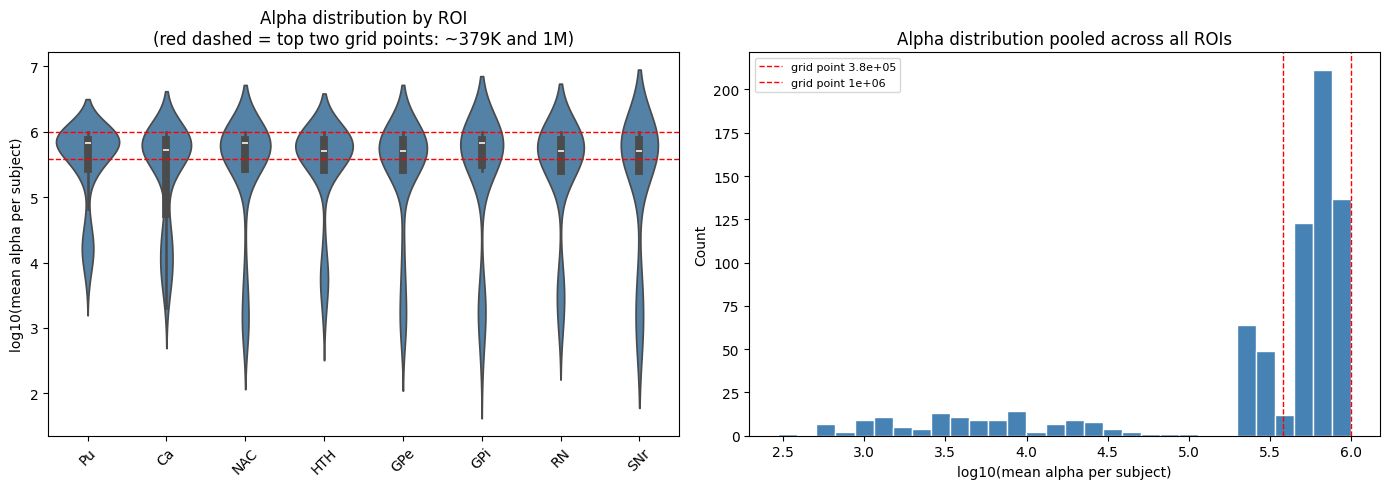

Fraction at or above penultimate grid point (~379K):
0.653


In [ ]:
# Alpha distributions
# mean_alpha is per-subject averaged over outer CV folds, not individual fold alphas — but it's what's available in roi_summary.csv.

alpha_grid = 10.0 ** np.linspace(-2, 6, 20)
grid_top2 = alpha_grid[-2:]  # [~379K, 1M

all_roi['log10_alpha'] = np.log10(all_roi['mean_alpha'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sns.violinplot(
    data=all_roi, x='roi_name', y='log10_alpha', ax=ax, inner='box', color='steelblue'
)
for a in grid_top2:
    ax.axhline(np.log10(a), color='red', linestyle='--', linewidth=1)
ax.set_xlabel('')
ax.set_ylabel('log10(mean alpha per subject)')
ax.set_title(
    'Alpha distribution by ROI\n(red dashed = top two grid points: ~379K and 1M)'
)
ax.tick_params(axis='x', rotation=45)

ax = axes[1]
ax.hist(all_roi['log10_alpha'], bins=30, color='steelblue', edgecolor='white')
for a in grid_top2:
    ax.axvline(
        np.log10(a),
        color='red',
        linestyle='--',
        linewidth=1,
        label=f'grid point {a:.2g}',
    )
ax.set_xlabel('log10(mean alpha per subject)')
ax.set_ylabel('Count')
ax.set_title('Alpha distribution pooled across all ROIs')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print('Fraction at or above penultimate grid point (~379K):')
print((all_roi['mean_alpha'] >= grid_top2[0]).mean().round(3))

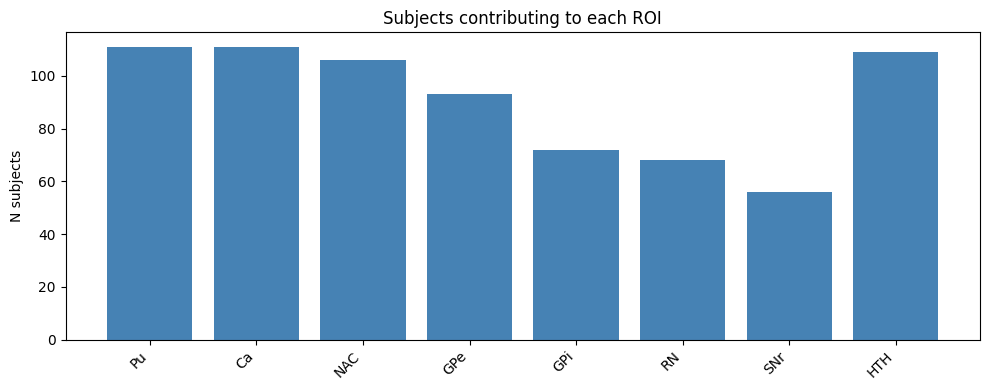

In [ ]:
# Variable since overlap of subject masks with ROIs must include at least 50 usable voxels
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(roi_grp['roi_name'], roi_grp['n_subs'], color='steelblue')
ax.set_ylabel('N subjects')
ax.set_title('Subjects contributing to each ROI')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 2  Voxel retention QC

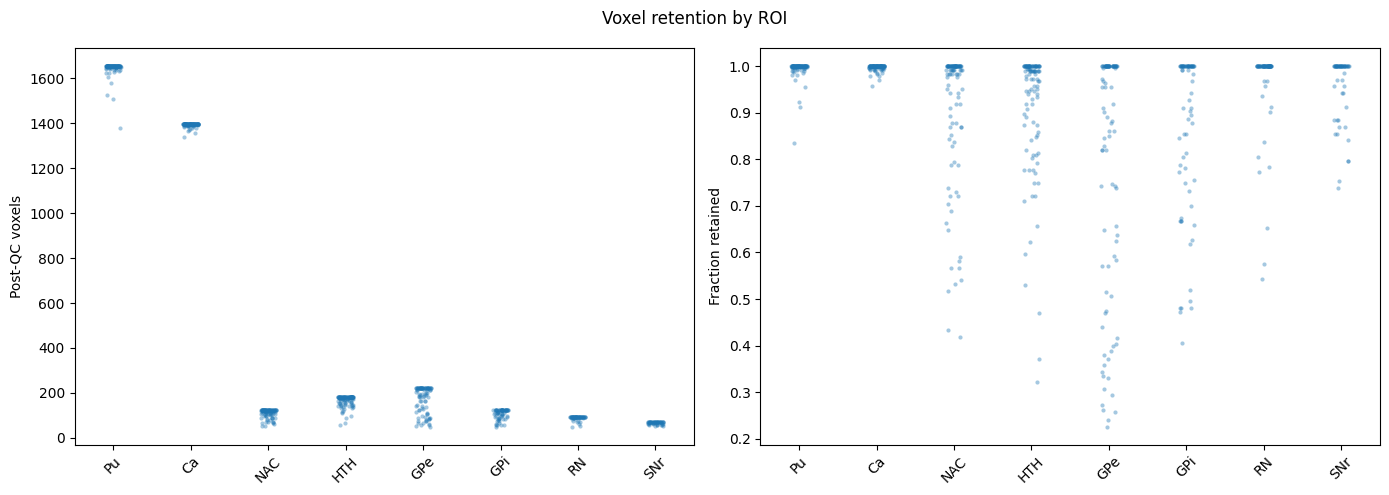

         n_vox_preQC                                                       \
               count    mean  std     min     25%     50%     75%     max   
roi_name                                                                    
Ca             111.0  1399.0  0.0  1399.0  1399.0  1399.0  1399.0  1399.0   
GPe             93.0   221.0  0.0   221.0   221.0   221.0   221.0   221.0   
GPi             72.0   123.0  0.0   123.0   123.0   123.0   123.0   123.0   
HTH            109.0   183.0  0.0   183.0   183.0   183.0   183.0   183.0   
NAC            106.0   122.0  0.0   122.0   122.0   122.0   122.0   122.0   
Pu             111.0  1655.0  0.0  1655.0  1655.0  1655.0  1655.0  1655.0   
RN              68.0    92.0  0.0    92.0    92.0    92.0    92.0    92.0   
SNr             56.0    69.0  0.0    69.0    69.0    69.0    69.0    69.0   

         n_vox_postQC                                                        
                count    mean   std     min     25%     50%     75%     ma

In [7]:
all_roi['frac_retained'] = all_roi['n_vox_postQC'] / all_roi['n_vox_preQC']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, ylabel in zip(
    axes,
    ['n_vox_postQC', 'frac_retained'],
    ['Post-QC voxels', 'Fraction retained'],
):
    sns.stripplot(
        data=all_roi, x='roi_name', y=col, ax=ax, alpha=0.4, size=3, jitter=True
    )
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('Voxel retention by ROI')
plt.tight_layout()
plt.show()

print(all_roi.groupby('roi_name')[['n_vox_preQC', 'n_vox_postQC']].describe().round(0))

## 3  Prediction performance

### Explaination for the figures below
The distributions of Fisher z(r) and R²_cv are centered just below zero for all ROIs,  confirming that out-of-sample predictions are no better than chance. Fisher z valuescluster around -0.04 to -0.09 across ROIs, and R²_cv values around -0.006 to -0.017, with virtually no subjects showing positive values. The consistency of this pattern — negative across all 8 ROIs and nearly all subjects — rules out the possibility that a subset of subjects or regions carry decodable signal that is being averaged away in the group summary. 

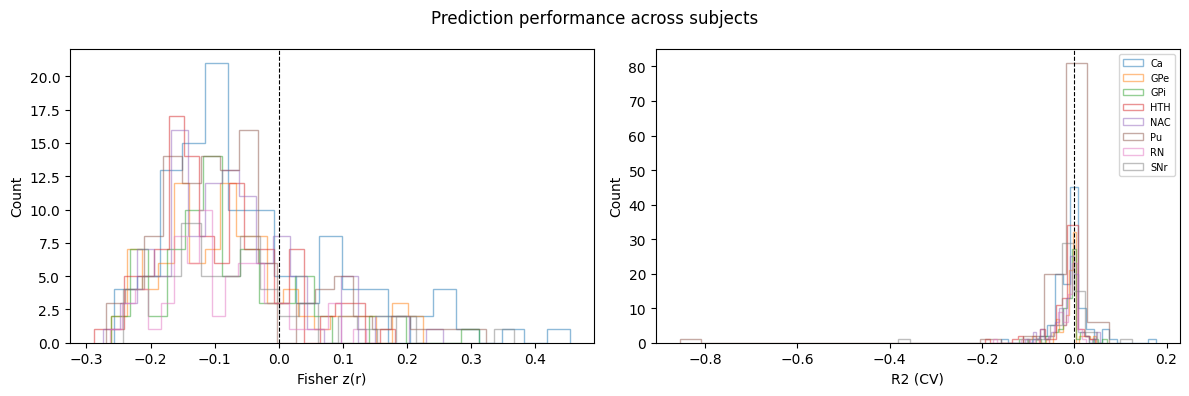

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, xlabel in zip(
    axes,
    ['fisher_z', 'r2_cv'],
    ['Fisher z(r)', 'R2 (CV)'],
):
    for roi_name, grp in all_roi.groupby('roi_name'):
        ax.hist(grp[col], bins=20, alpha=0.5, label=roi_name, histtype='step')
    ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
axes[1].legend(loc='upper right', fontsize=7)
plt.suptitle('Prediction performance across subjects')
plt.tight_layout()
plt.show()

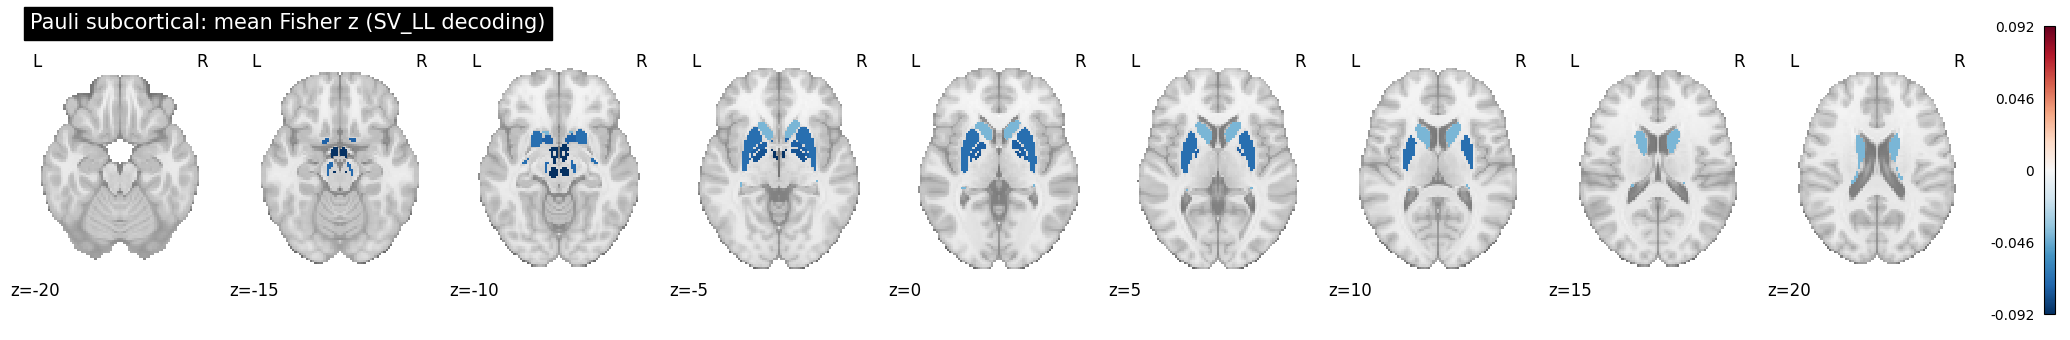

In [10]:
atlas_img = nib.load(str(ATLAS_PATH))
atlas_data = atlas_img.get_fdata().astype(int)
stat_map_data = np.zeros(atlas_data.shape, dtype=float)
for _, row in roi_grp.iterrows():
    stat_map_data[atlas_data == int(row['roi_label'])] = row['mean_fisher_z']

stat_img = nib.Nifti1Image(stat_map_data, atlas_img.affine)
plotting.plot_stat_map(
    stat_img,
    display_mode='z',
    cut_coords=range(-20, 25, 5),
    colorbar=True,
    title='Pauli subcortical: mean Fisher z (SV_LL decoding)',
    symmetric_cbar=True,
)
plt.show()

## 4  Trial-wise checks

In [11]:
tw_files = sorted(OUT_ROOT.glob('sub-*/trialwise_preds.csv'))
tw_all = pd.concat([pd.read_csv(f) for f in tw_files], ignore_index=True)
tw_all = tw_all.merge(roi_labels, on='roi_label', how='left')
tw_all['run'] = tw_all['run'].astype(str)
print(f'{len(tw_all)} trial x ROI rows from {tw_all["sub_id"].nunique()} subjects')
tw_all.head()

78472 trial x ROI rows from 111 subjects


,sub_id,roi_label,run,trial_type,Delay,amount,choseAccept,y,yhat_oos,roi_name
0,dmp0011,1,1,trial00,58,66,1.0,29.118120,12.391465,Pu
1,dmp0011,1,1,trial01,95,39,0.0,12.684361,14.442231,Pu
2,dmp0011,1,1,trial02,172,69,0.0,14.507342,13.983769,Pu
3,dmp0011,1,1,trial03,42,23,0.0,11.996570,16.227545,Pu
4,dmp0011,1,1,trial04,142,77,1.0,18.775637,15.997893,Pu


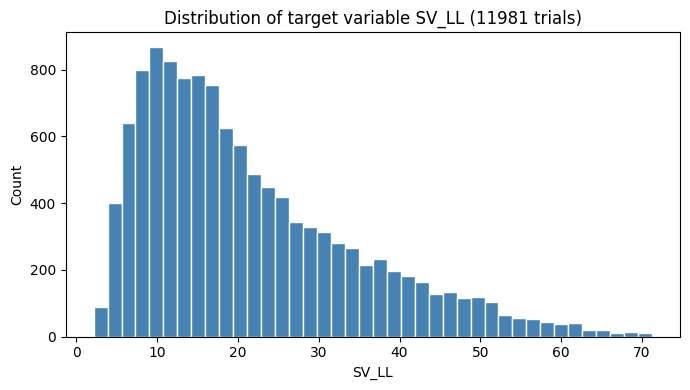

count    11981.000
mean        21.443
std         13.307
min          2.135
25%         11.239
50%         17.847
75%         28.853
max         71.257
Name: y, dtype: float64


In [12]:
# Use first ROI only to avoid counting each trial once per ROI
first_roi = int(tw_all['roi_label'].iloc[0])
sv_df = tw_all[tw_all['roi_label'] == first_roi][['sub_id', 'y']].copy()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(sv_df['y'], bins=40, color='steelblue', edgecolor='white')
ax.set_xlabel('SV_LL')
ax.set_ylabel('Count')
ax.set_title(f'Distribution of target variable SV_LL ({len(sv_df)} trials)')
plt.tight_layout()
plt.show()

print(sv_df['y'].describe().round(3))

### Explaination the figure below
Ridge regression trades off increased bias (in betas) for a reduced variance.  The hope is the reduced variance is helpful, but in this case the regularization is so strong (bias is high) that the variance is greatly reduced and our predicted values are much, much less variable than the observed.  This limits any ability to predict.

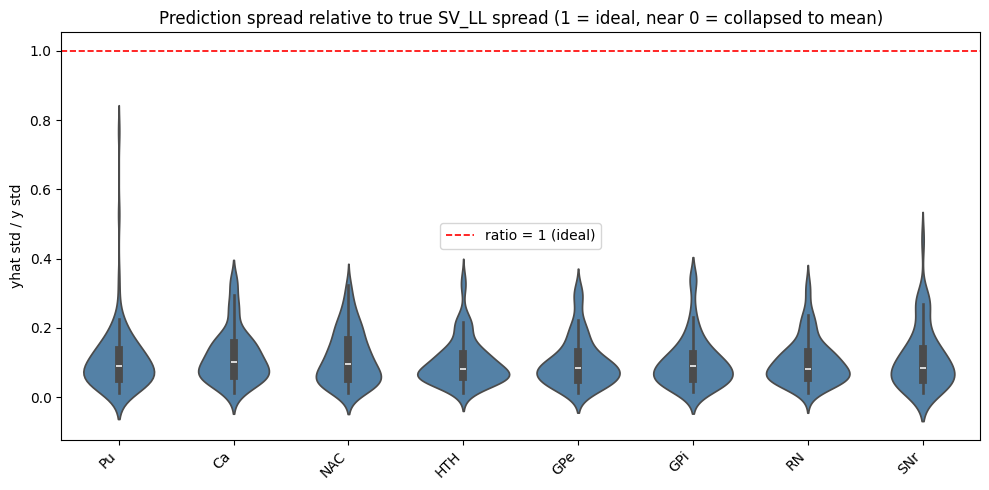

          count   mean    std    min    25%    50%    75%    max
roi_name                                                        
Ca        111.0  0.118  0.076  0.012  0.060  0.102  0.156  0.337
GPe        93.0  0.101  0.070  0.012  0.050  0.083  0.130  0.314
GPi        72.0  0.101  0.073  0.015  0.052  0.089  0.124  0.342
HTH       109.0  0.101  0.066  0.012  0.057  0.082  0.126  0.348
NAC       106.0  0.115  0.077  0.012  0.051  0.095  0.165  0.324
Pu        111.0  0.108  0.096  0.012  0.052  0.090  0.136  0.768
RN         68.0  0.103  0.066  0.012  0.056  0.083  0.130  0.325
SNr        56.0  0.113  0.090  0.011  0.051  0.085  0.139  0.454


In [13]:
std_df = (
    tw_all.groupby(['sub_id', 'roi_label'])[['y', 'yhat_oos']]
    .std()
    .rename(columns={'y': 'y_std', 'yhat_oos': 'yhat_std'})
    .reset_index()
)
std_df['std_ratio'] = std_df['yhat_std'] / std_df['y_std']
by_sub_roi = std_df.merge(roi_labels, on='roi_label', how='left')

fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(
    data=by_sub_roi, x='roi_name', y='std_ratio', ax=ax, inner='box', color='steelblue'
)
ax.axhline(1.0, color='red', linestyle='--', linewidth=1.2, label='ratio = 1 (ideal)')
ax.set_xlabel('')
ax.set_ylabel('yhat std / y std')
ax.set_title(
    'Prediction spread relative to true SV_LL spread (1 = ideal, near 0 = collapsed to mean)'
)
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(by_sub_roi.groupby('roi_name')['std_ratio'].describe().round(3))

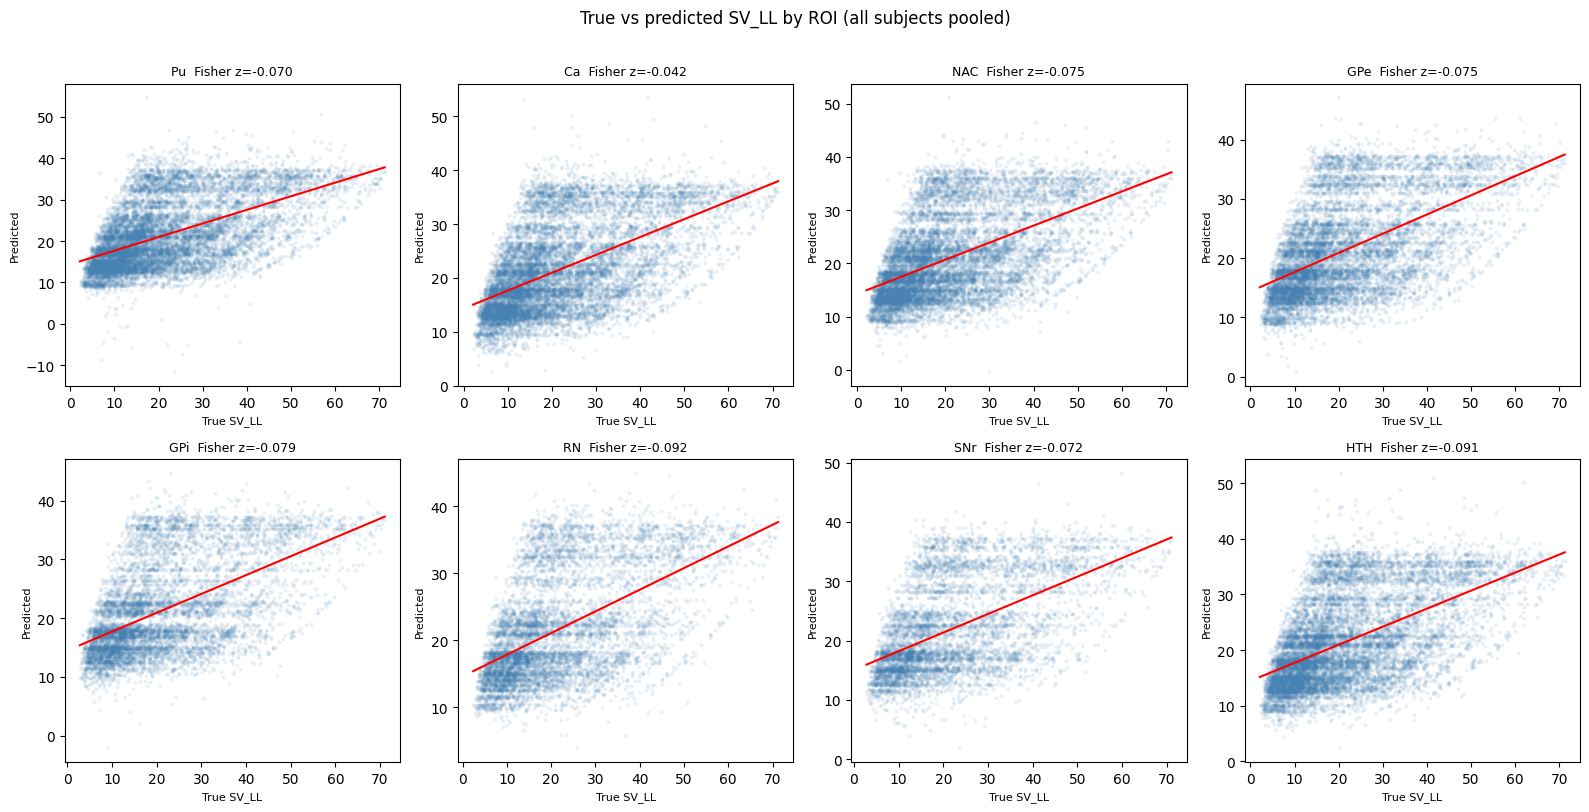

In [14]:
roi_list = roi_grp['roi_label'].tolist()
ncols = 4
nrows = (len(roi_list) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = np.array(axes).flatten()

for i, roi_lab in enumerate(roi_list):
    ax = axes[i]
    sub = tw_all[tw_all['roi_label'] == roi_lab]
    rname = roi_grp.loc[roi_grp['roi_label'] == roi_lab, 'roi_name'].iloc[0]
    fz = roi_grp.loc[roi_grp['roi_label'] == roi_lab, 'mean_fisher_z'].iloc[0]
    ax.scatter(
        sub['y'], sub['yhat_oos'], alpha=0.08, s=4, rasterized=True, color='steelblue'
    )
    m, b = np.polyfit(sub['y'], sub['yhat_oos'], 1)
    xs = np.linspace(sub['y'].min(), sub['y'].max(), 100)
    ax.plot(xs, m * xs + b, color='red', linewidth=1.5)
    ax.set_title(f'{rname}  Fisher z={fz:.3f}', fontsize=9)
    ax.set_xlabel('True SV_LL', fontsize=8)
    ax.set_ylabel('Predicted', fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('True vs predicted SV_LL by ROI (all subjects pooled)', y=1.01)
plt.tight_layout()
plt.show()

## 5  Baseline model and delay analysis

Baseline = leave-one-run-out training mean of SV_LL (per subject × run).  
`delta_se = SE_model - SE_baseline`: negative means the ridge model beats the naive mean.

Delay analysis asks whether residual prediction error (delta_se) correlates with
log(Delay). FDR correction applied across ROIs.

In [15]:
parts = []
for (sub_id, roi_lab), grp in tw_all.groupby(['sub_id', 'roi_label']):
    grp = grp.copy()
    yhat_base = np.full(len(grp), np.nan)
    for run_id in grp['run'].unique():
        test_mask = grp['run'] == run_id
        yhat_base[test_mask.values] = grp.loc[~test_mask, 'y'].mean()
    grp['yhat_base'] = yhat_base
    parts.append(grp)

tw_err = pd.concat(parts, ignore_index=True)
tw_err['se_model'] = (tw_err['y'] - tw_err['yhat_oos']) ** 2
tw_err['se_base'] = (tw_err['y'] - tw_err['yhat_base']) ** 2
tw_err['delta_se'] = tw_err['se_model'] - tw_err['se_base']
tw_err['logDelay'] = np.log(tw_err['Delay'])

print('Mean delta_se by ROI (negative = model beats naive baseline):')
print(tw_err.groupby('roi_name')['delta_se'].mean().round(4))

Mean delta_se by ROI (negative = model beats naive baseline):
roi_name
Ca     0.9809
GPe    1.1653
GPi    1.4438
HTH    2.0285
NAC    1.6309
Pu     1.8247
RN     1.8354
SNr    1.2748
Name: delta_se, dtype: float64


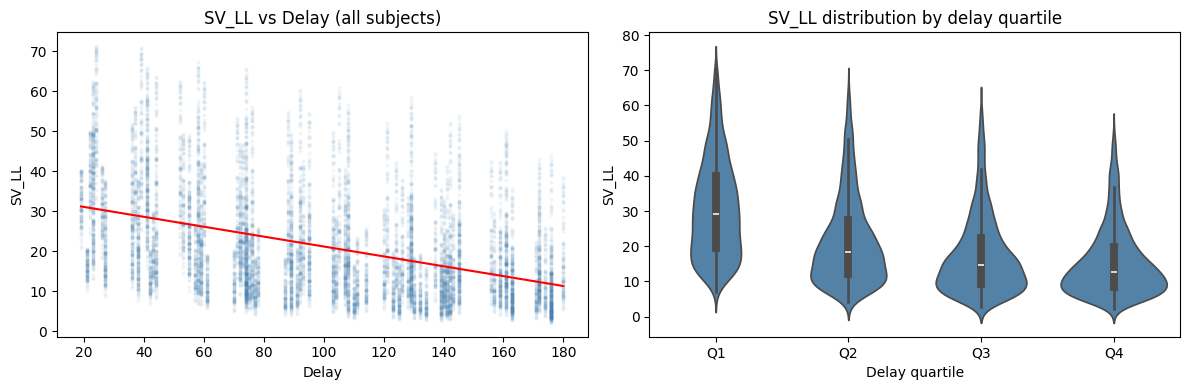

corr(Delay, SV_LL) = -0.435, p = 0.000e+00
            count   mean    std   min    25%    50%    75%    max
delay_bin                                                        
Q1         3091.0  30.83  13.94  6.87  19.44  29.05  39.99  71.26
Q2         3018.0  21.52  12.34  4.04  12.03  18.38  27.42  65.68
Q3         2899.0  17.50  11.10  2.75   9.30  14.67  22.43  60.76
Q4         2973.0  15.45   9.71  2.14   8.43  12.78  19.77  53.80


/tmp/ipykernel_20307/237371682.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(one_roi.groupby('delay_bin')['y'].describe().round(2))


In [ ]:
# Look at SV_LL as a function of delay
# Use one ROI to avoid duplicating trials
one_roi = tw_all[tw_all['roi_label'] == tw_all['roi_label'].iloc[0]][
    ['sub_id', 'Delay', 'y']
].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scatter with regression line
ax = axes[0]
ax.scatter(
    one_roi['Delay'], one_roi['y'], alpha=0.05, s=4, color='steelblue', rasterized=True
)
m, b = np.polyfit(one_roi['Delay'], one_roi['y'], 1)
xs = np.linspace(one_roi['Delay'].min(), one_roi['Delay'].max(), 100)
ax.plot(xs, m * xs + b, color='red', linewidth=1.5)
ax.set_xlabel('Delay')
ax.set_ylabel('SV_LL')
ax.set_title('SV_LL vs Delay (all subjects)')

# Violin by delay bin
ax = axes[1]
one_roi['delay_bin'] = pd.qcut(one_roi['Delay'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
sns.violinplot(
    data=one_roi, x='delay_bin', y='y', ax=ax, inner='box', color='steelblue'
)
ax.set_xlabel('Delay quartile')
ax.set_ylabel('SV_LL')
ax.set_title('SV_LL distribution by delay quartile')

plt.tight_layout()
plt.show()

r, p = stats.pearsonr(one_roi['Delay'], one_roi['y'])
print(f'corr(Delay, SV_LL) = {r:.3f}, p = {p:.3e}')
print(one_roi.groupby('delay_bin')['y'].describe().round(2))

In [16]:
def sub_roi_delay_corr(grp):
    x = grp['logDelay'].values
    d = grp['delta_se'].values
    valid = np.isfinite(x) & np.isfinite(d)
    if valid.sum() < 5 or x[valid].std() < 1e-6 or d[valid].std() < 1e-6:
        return pd.Series({'r': np.nan})
    r, _ = stats.pearsonr(x[valid], d[valid])
    return pd.Series({'r': r})


corr_delay = (
    tw_err.groupby(['sub_id', 'roi_label'])
    .apply(sub_roi_delay_corr)
    .reset_index()
    .merge(roi_labels, on='roi_label', how='left')
    .dropna(subset=['r'])
)
corr_delay['fisher_z'] = np.arctanh(np.clip(corr_delay['r'], -0.999999, 0.999999))


def roi_delay_summary(grp):
    z = grp['fisher_z'].dropna().values
    if len(z) < 3:
        return pd.Series(
            {
                'mean_z': np.nan,
                'n': len(z),
                't': np.nan,
                'p': np.nan,
                'ci_lo': np.nan,
                'ci_hi': np.nan,
            }
        )
    t_stat, p_val = stats.ttest_1samp(z, 0)
    ci_lo, ci_hi = stats.t.interval(
        0.95, df=len(z) - 1, loc=z.mean(), scale=stats.sem(z)
    )
    return pd.Series(
        {
            'mean_z': z.mean(),
            'n': len(z),
            't': t_stat,
            'p': p_val,
            'ci_lo': ci_lo,
            'ci_hi': ci_hi,
        }
    )


roi_delay = (
    corr_delay.groupby(['roi_label', 'roi_name'])
    .apply(roi_delay_summary)
    .reset_index()
    .sort_values('roi_label')
)

p_vals = roi_delay['p'].values.astype(float)
valid_mask = ~np.isnan(p_vals)
reject = np.zeros(len(p_vals), dtype=bool)
pvals_fdr = np.full(len(p_vals), np.nan)
if valid_mask.sum() > 1:
    rej, pcorr, _, _ = multipletests(p_vals[valid_mask], method='fdr_bh')
    reject[valid_mask] = rej
    pvals_fdr[valid_mask] = pcorr

roi_delay['p_fdr'] = pvals_fdr
roi_delay['sig_fdr'] = reject

roi_delay[['roi_name', 'n', 'mean_z', 'ci_lo', 'ci_hi', 'p', 'p_fdr', 'sig_fdr']].round(
    4
)

/tmp/ipykernel_20307/1309903458.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(sub_roi_delay_corr)
/tmp/ipykernel_20307/1309903458.py:52: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(roi_delay_summary)


,roi_name,n,mean_z,ci_lo,ci_hi,p,p_fdr,sig_fdr
0,Pu,111.0,-0.1013,-0.1497,-0.0528,0.0001,0.0002,True
1,Ca,111.0,-0.0624,-0.1093,-0.0155,0.0095,0.0109,True
2,NAC,106.0,-0.0585,-0.0969,-0.0200,0.0032,0.0052,True
3,GPe,93.0,-0.0822,-0.1310,-0.0334,0.0012,0.0024,True
4,GPi,72.0,-0.0572,-0.1073,-0.0072,0.0256,0.0256,True
5,RN,68.0,-0.1170,-0.1664,-0.0677,0.0000,0.0001,True
6,SNr,56.0,-0.0703,-0.1199,-0.0206,0.0064,0.0085,True
7,HTH,109.0,-0.0847,-0.1249,-0.0445,0.0001,0.0002,True


### Explanation of the results below

**What this analysis aims to do**. This analysis asked whether the model's prediction errors were related to the delay of each trial. For each trial, we compared the model's squared error to that of a simple baseline (the leave-one-run-out training mean), giving delta_se — negative when the model beats the  baseline, positive when it does not. We then correlated delta_se with log(Delay) for each subject and ROI. A significant negative correlation would mean the model does better relative to baseline on longer-delay trials. All ROIs showed FDR-significant negative correlations,  but this reflects a behavioral artifact: SV_LL decreases systematically with delay, so the  training mean overpredicts for long-delay trials and both the model and baseline are affected in the same way. The effect is driven by the SV_LL-delay relationship, not by the model learning delay-specific neural patterns.     


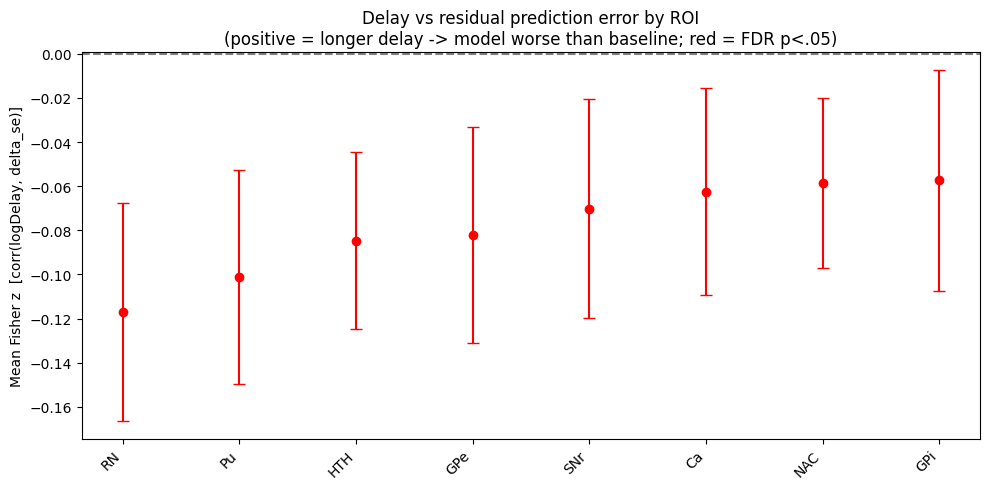

In [ ]:
roi_delay_sorted = roi_delay.sort_values('mean_z').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
for j, row in roi_delay_sorted.iterrows():
    color = 'red' if bool(row['sig_fdr']) else 'steelblue'
    err_lo = row['mean_z'] - row['ci_lo'] if pd.notna(row['ci_lo']) else 0
    err_hi = row['ci_hi'] - row['mean_z'] if pd.notna(row['ci_hi']) else 0
    ax.errorbar(
        j,
        row['mean_z'],
        yerr=[[err_lo], [err_hi]],
        fmt='o',
        color=color,
        ecolor=color,
        capsize=4,
        markersize=6,
    )

ax.axhline(0, color='k', linestyle='--', alpha=0.5)
ax.set_xticks(range(len(roi_delay_sorted)))
ax.set_xticklabels(roi_delay_sorted['roi_name'], rotation=45, ha='right')
ax.set_ylabel('Mean Fisher z  [corr(logDelay, delta_se)]')
ax.set_title(
    ''
)Delay vs residual prediction error by ROI\n'
    '(positive = longer delay -> model worse than baseline; red = FDR p<.05)
plt.tight_layout()
plt.show()